## Import the CIFAR-10


In [1]:
# libs needed
import tarfile
import pickle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
print("ok")

ok


## Load the data


In [2]:
with tarfile.open("cifar-10-python.tar.gz", "r:gz") as tar:
    tar.extractall()

# from https://www.cs.toronto.edu/~kriz/cifar.html
# Using the unpickle function, each of the bach files contains a dictionary with the following contents:
#   data --> a 10000x3072 numpy array of uint8's.
#       - Each row of the array stores a 32x32 colour image.
#       - Where the first 1024 entries contain the red channel, then 1024 for green, and then 1024 for blue
#       - The image is stored in row-major order, so the first 32 entries of the array are red channel values of the first row of the image
# SÅ data[i] indeholder 3 arrays af 1024 hver --> [ R (1024 values), G (1024 values), B (1024 values) ]
#

#   labels --> a list of 10000 numbers in the range 0-9
#       - The number at index i indicates the label of the i'th image in the array data

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

/tmp/ipykernel_81101/3756646088.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


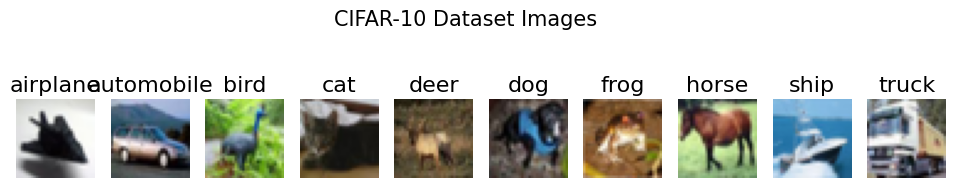

In [3]:
x_train = [] # the data
y_train = [] # the labels

for i in range(1,6):
  dict_train = unpickle(f'cifar-10-batches-py/data_batch_{i}')
  x_train.append(dict_train[b'data'])
  y_train.append(dict_train[b'labels'])

# Make them a long list instead of a list of lists
x_train = np.concatenate(x_train)
y_train = np.concatenate(y_train)

# The test data
dict_test = unpickle(f'cifar-10-batches-py/test_batch')
x_test = dict_test[b'data']
y_test = dict_test[b'labels']

# reshape so we get 50000,3,32,32 --> https://github.com/n-kostadinov/cnn-image-classification-cifar-10-from-scratch/blob/master/cnn-image-classification-cifar-10-from-scratch.ipynb

#features = batch['data'].reshape((len(batch['data']), 3, 32, 32)).transpose(0, 2, 3, 1)
x_train = x_train.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0   # (N, C, H, W)
# x_train = x_train.transpose(0, 2, 3, 1)    # (N, H, W, C)

x_test  = x_test.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
# x_test = x_test.transpose(0, 2, 3, 1)


# total size
n_train = x_train.shape[0]
n_test = x_test.shape[0]
n_total = n_train + n_test





# ------------------------------------------------------------
# pick one example of each digit
# ------------------------------------------------------------
examples = []

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    img = np.transpose(x_train[idx], (1, 2, 0))   # CHW -> HWC only for plotting
    examples.append(img)


# ------------------------------------------------------------
# create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))

gs = fig.add_gridspec(2, 10, height_ratios=[1,1.2])

# title
fig.suptitle("CIFAR-10 Dataset Images", fontsize=15)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# ------------------------------------------------------------
# row of example digits
# ------------------------------------------------------------
for i in range(10):
    ax = fig.add_subplot(gs[0,i])

    ax.imshow(examples[i])
    # ax.set_title(str(i), fontsize=16)
    ax.set_title(str(classes[i]), fontsize=16)
    ax.axis("off")


## Convert to torch tensors

In [4]:
X = torch.tensor(x_train, dtype=torch.float32)
Y = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(x_test, dtype=torch.float32)
Y_test = torch.tensor(y_test, dtype=torch.long)

# Setting up the CNN


In [5]:
# import torch.nn.functional as F

# class SmallCNN(nn.Module):
#     def __init__(self, num_filters=32, hidden_size=64, num_classes=10):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_channels=3, out_channels=num_filters, kernel_size=3)
#         self.relu = nn.ReLU()
#         self.pool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc1 = nn.Linear(num_filters, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, num_classes)

#     def forward(self, x):
#         x=self.conv1(x)
#         x=self.relu(x)
#         x=torch.mean(x,dim=(2,3))

#         x = self.fc1(x)
#         x = self.relu(x)
#         x = self.fc2(x)
#         # x = F.softmax(x, dim=1) # Apply softmax across the class dimension
#         return x

In [6]:
import torch
# all nn libraries nn.layer, convs and loss functions

import torch.nn as nn
# Display Image

from IPython.display import Image

# visualisation
# !pip install torchview transformers
import torchvision
from torchview import draw_graph

# !pip install transformers
from transformers import MobileNetV1Config, MobileNetV1Model

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)



########################################################3


class DepthWiseSeperable(nn.Module):

    def __init__(self, in_channels , out_channels , stride ):
        """
        DepthWiseSeperable block of MobileNet which performs the following operations:
        (a) depthwise convolution by applying a separate filter for each channel
        (b) pointwise convolutions are applied which combine the filtered result by implementing 1 × 1 convolution
        
            Note:
                1. groups = in_channels used for depthwise convolution
                2. in_channels and out_channels are same for depthwise convolution
                3. bias = False due to the usage of BatchNorm 
                4. To generate same height and width of output feature map as the input feature map, following should be padding for
                    * 1x1 conv : p=0
                    * 3x3 conv : p=1
                    * 5x5 conv : p=2


        Args:
          in_channels (int) : number of input channels
          out_channels (int) : number of output channels 
          stride (int) : stride used for depthwise convolution

        Attributes:
            Depthwise seperable convolutional block

        """

        super(DepthWiseSeperable,self).__init__()
        
        # groups used here
        self.depthwise = nn.Conv2d(in_channels = in_channels , out_channels = in_channels , stride = stride , padding = 1, kernel_size = 3 , groups=in_channels , bias = False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels = in_channels , out_channels = out_channels , stride = 1 , padding = 0, kernel_size = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        
        return x



################################################################################################33


class MobileNetV1(nn.Module):
    
    def __init__(self, num_classes=10):
        
        super(MobileNetV1, self).__init__()

        # Initial convolution layer
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias = False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
        )
        
        # Depthwise separable convolutions
        self.features = nn.Sequential(
            self.features,                      # Inserting the above features here
            DepthWiseSeperable(32, 64, 1),
            DepthWiseSeperable(64, 128, 2),
            DepthWiseSeperable(128, 128, 1),
            DepthWiseSeperable(128, 256, 2),
            DepthWiseSeperable(256, 256, 1),
            DepthWiseSeperable(256, 512, 2),
            
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),

            DepthWiseSeperable(512, 1024, 2),
            DepthWiseSeperable(1024, 1024, 1)

        )
        
        # Average pooling and classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

/home/akselu24/Documents/AI_Tools_F26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


# Function used for training for one epoch

In [ ]:
def train_one_epoch(model, loss_fcn, optimizer):
    model.train()
    loss_tracking = 0
    number_of_correct = 0
    number_of_parameters = 0

    for i, 

# Training the model

In [ ]:
import torch.optim as optim

# Instantiate the model
model = MobileNetV1().to(device)


# Define loss function and optimizer
lossFunction = nn.CrossEntropyLoss()
learningRate = 0.001
optimizer = optim.Adam(params=model.parameters(), lr=learningRate)


# Number of steps for training
num_steps = 2
batch_size = 256


# Training loop
for step in range(num_steps):
 
    idx = torch.randperm(X.size(0))[:batch_size]
    X_batch = X[idx]
    Y_batch = Y[idx]
    
    # Forward pass
    outputs = model(X_batch)
    loss = criterion(outputs, Y_batch)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (step+1) % 100 == 0:
      train_preds = torch.argmax(outputs, dim=1)
      train_acc = (train_preds == Y_batch).float().mean().item() * 100

      print(f'Step [{step+1}/{num_steps}], Loss: {loss.item():.4f}, Train acc: {train_acc:.2f}%')



print('Training finished.')

Step [100/4000], Loss: 1.8204, Train acc: 32.42%
Step [200/4000], Loss: 1.6184, Train acc: 39.06%
Step [300/4000], Loss: 1.3444, Train acc: 49.61%
Step [400/4000], Loss: 1.2819, Train acc: 54.69%
Step [500/4000], Loss: 1.3779, Train acc: 53.91%
Step [600/4000], Loss: 1.2820, Train acc: 53.52%
Step [700/4000], Loss: 1.1324, Train acc: 59.38%
Step [800/4000], Loss: 1.0923, Train acc: 62.50%
Step [900/4000], Loss: 1.1469, Train acc: 60.16%
Step [1000/4000], Loss: 1.1285, Train acc: 60.16%
Step [1100/4000], Loss: 0.9077, Train acc: 71.48%
Step [1200/4000], Loss: 0.9404, Train acc: 66.80%
Step [1300/4000], Loss: 0.9652, Train acc: 65.62%
Step [1400/4000], Loss: 0.8209, Train acc: 73.44%
Step [1500/4000], Loss: 0.8270, Train acc: 74.61%
Step [1600/4000], Loss: 0.7271, Train acc: 73.44%
Step [1700/4000], Loss: 0.5772, Train acc: 82.03%
Step [1800/4000], Loss: 0.6574, Train acc: 77.34%
Step [1900/4000], Loss: 0.6049, Train acc: 80.47%
Step [2000/4000], Loss: 0.5521, Train acc: 83.59%
Step [210

# Evaluate the model

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

model.eval()

def get_predictions(model, X, Y, batch_size=256):
    all_preds = []
    all_true = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            X_batch = X[i:i+batch_size]
            Y_batch = Y[i:i+batch_size]

            outputs = model(X_batch)              # logits
            preds = torch.argmax(outputs, dim=1)  # predicted class index

            all_preds.append(preds.cpu())
            all_true.append(Y_batch.cpu())

    y_pred = torch.cat(all_preds)
    y_true = torch.cat(all_true)
    return y_true, y_pred


# Get predictions
y_true_train, y_pred_train = get_predictions(model, X, Y)
y_true_test, y_pred_test = get_predictions(model, X_test, Y_test)

# Accuracy
train_acc = (y_pred_train == y_true_train).float().mean().item() * 100
test_acc = (y_pred_test == y_true_test).float().mean().item() * 100

print(f"Accuracy on training data: {train_acc:.2f}%")
print(f"Accuracy on test data: {test_acc:.2f}%")

# Class names
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Classification report
print("\nClassification report on test data:")
print(classification_report(y_true_test.numpy(), y_pred_test.numpy(), target_names=classes))

Accuracy on training data: 90.02%
Accuracy on test data: 56.41%

Classification report on test data:
              precision    recall  f1-score   support

    airplane       0.60      0.64      0.62      1000
  automobile       0.66      0.71      0.68      1000
        bird       0.45      0.51      0.48      1000
         cat       0.40      0.33      0.36      1000
        deer       0.50      0.46      0.48      1000
         dog       0.46      0.45      0.46      1000
        frog       0.63      0.65      0.64      1000
       horse       0.60      0.57      0.59      1000
        ship       0.69      0.67      0.68      1000
       truck       0.63      0.63      0.63      1000

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.56     10000
weighted avg       0.56      0.56      0.56     10000



## Visualize the confusion matrix


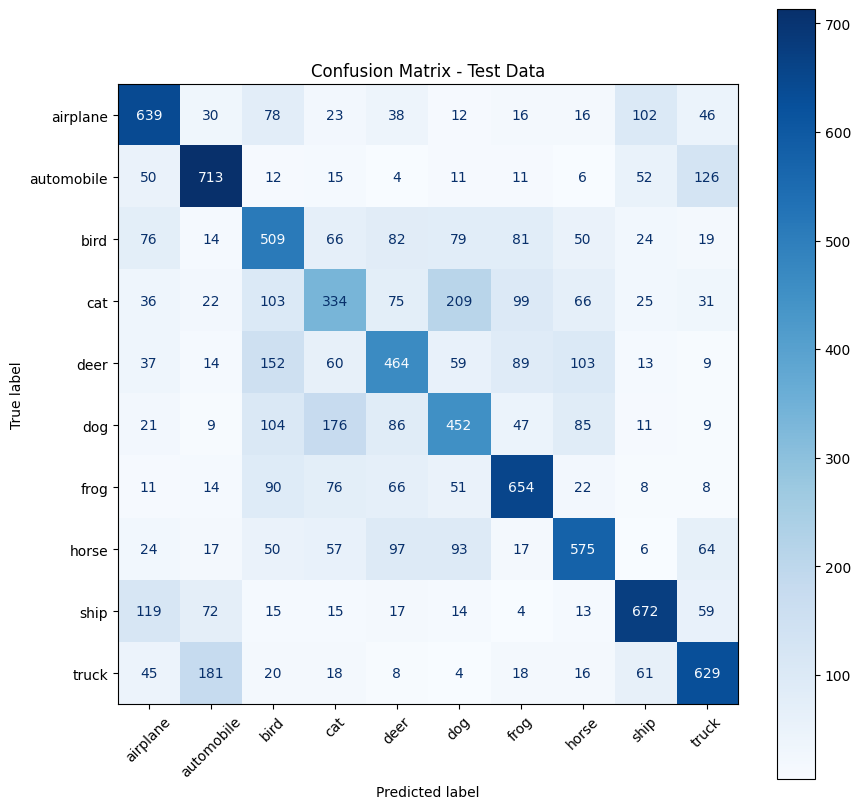

In [9]:
# Confusion matrix
cm = confusion_matrix(y_true_test.numpy(), y_pred_test.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - Test Data")
plt.show()